# EURO-LABS 2026: Advanced Training School on Operation of Accelerators
*T. Prebibaj, F. Asvesta

---

# Tracking with Xsuite

Tracking in a real accelerator lattice with the tracking code [Xsuite](https://xsuite.readthedocs.io/en/latest/).

---

In [3]:
# Import xsuite modules and other libraries
import xtrack as xt
import xpart as xp
import xdeps as xd
import xplt
import xfields as xf


from cpymad.madx import Madx
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import nafflib


/Users/fasvesta/miniforge3/envs/xsuite_env/lib/python3.11/site-packages/xplt/hooks.py:31: RuntimeWarning: Failed to register formatters with pint: No module named 'pint'
  warnings.warn(f"Failed to register formatters with pint: {e}", RuntimeWarning)


## The CERN Proton Synchrotron Booster (PSB)

<p align="center">
<img src=./images_lectures/psb.png width="40%">
</p>

- PSB consists of 4 identical, vertically stacked rings with commin injection and extraction lines. 

- It accelerates protons from $160$ MeV to $2$ GeV in $1.2$ seconds for high-intensity and high-brightness physics. 

- Beam intensities rage from $10^{10}$ to $10^{13}$ protons per ring and the beam emittances from $1$ mm mrad to $15$ mm mrad.

### Exercise 1: load and plot the layout of the PSB

Load the PSB line to Xsuite from the MAD-X sequence and plot it using xplt.

In [4]:
# The MAD-X sequence is at the psb/psb.seq file. The aperture of each element is defined at psb/psb_aperture.dbx
mad = Madx()
mad.options.echo = False # to not print the stdout of MAD-X  
mad.chdir('psb')
mad.call('psb_flat_bottom.madx') # loads the PSB sequence, aperture, etc. in MAD-X
line= xt.Line.from_madx_sequence(mad.sequence['psb1'],
                                 deferred_expressions=True,
                                 allow_thick=True)


  ++++++++++++++++++++++++++++++++++++++++++++
  +     MAD-X 5.09.03  (64 bit, Darwin)      +
  + Support: mad@cern.ch, http://cern.ch/mad +
  + Release   date: 2024.04.25               +
  + Execution date: 2026.07.10 10:27:51      +
  ++++++++++++++++++++++++++++++++++++++++++++
++++++ info: seqedit - number of elements installed:  0
++++++ info: seqedit - number of elements moved:      0
++++++ info: seqedit - number of elements removed:    0
++++++ info: seqedit - number of elements replaced:   0
++++++ info: seqedit - number of elements installed:  1
++++++ info: seqedit - number of elements moved:      0
++++++ info: seqedit - number of elements removed:    0
++++++ info: seqedit - number of elements replaced:   0


Converting sequence "psb1":   0%|          | 0/530 [00:00<?, ?it/s]

In [5]:
# Check elements
line_table = line.get_table()
line_table_df = line_table.to_pandas()
line_table_df[0:20]

,s,element_type,name,isthick,isreplica,parent_name,iscollective,s_start,s_center,s_end,env_name
0,0.000000,Marker,psb1$start,False,False,None,False,0.000000,0.000000,0.000000,psb1$start
1,0.000000,Marker,p01ring1$start,False,False,None,False,0.000000,0.000000,0.000000,p01ring1$start
2,0.000000,Drift,drift_0,True,False,None,False,0.000000,0.089750,0.179500,drift_0
3,0.179500,RBend,bi1.bsw1l1.1,True,False,None,False,0.179500,0.336000,0.492500,bi1.bsw1l1.1
4,0.492500,Drift,drift_1,True,False,None,False,0.492500,0.681000,0.869500,drift_1
5,0.869500,RBend,bi1.bsw1l1.2,True,False,None,False,0.869500,1.032000,1.194500,bi1.bsw1l1.2
6,1.194500,Drift,drift_2,True,False,None,False,1.194500,1.261064,1.327628,drift_2
7,1.327628,Drift,bi1.btv1l1,True,False,None,False,1.327628,1.327628,1.327628,bi1.btv1l1
8,1.327628,Drift,drift_3,True,False,None,False,1.327628,1.330814,1.334000,drift_3
9,1.334000,Drift,bi1.bcsf1l1,True,False,None,False,1.334000,1.334000,1.334000,bi1.bcsf1l1


In [4]:
# Get circumference
print('PSB circumference in meters: ', line.get_length()) 

PSB circumference in meters:  157.07999999999973


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


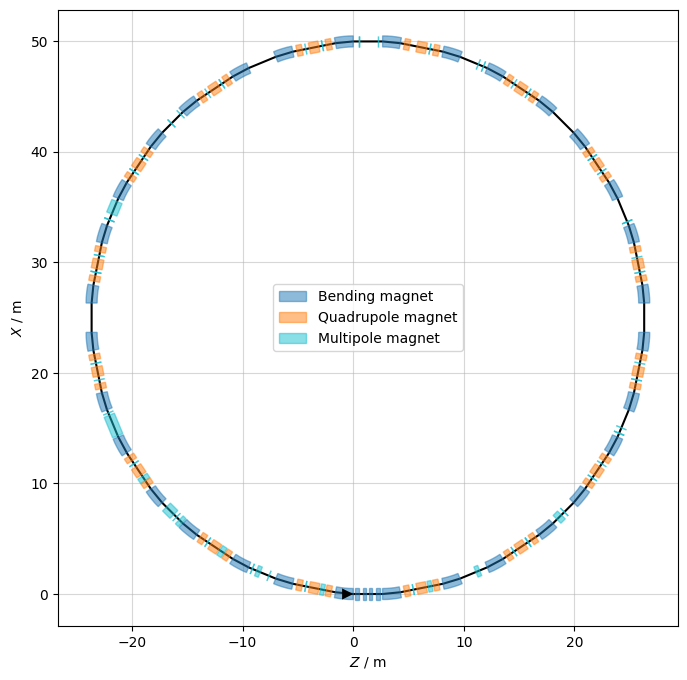

In [5]:
survey = line.survey()
plot = xplt.FloorPlot(survey, labels="S.Q.", figsize=(8,8))
plot.legend()

- The PSB ring consists of 16 identical cells with a total circumference of $157.08$ meters (relatively similar with the cases we have seen so far).

- Each cell (or period or sector) consists of one defocusing and two focusing quadrupoles, two dipoles and many higher order magnets (sextupoles, octupoles, etc). 

### Exercise 2: optics functions of PSB

Use the line.twiss() method of Xsuite to compute the optics functions around the PSB and plot them.

In [6]:
# We need to add a reference particle for the twiss calculation (mass, energy)
line.particle_ref=xp.Particles(mass0=xp.PROTON_MASS_EV,gamma0=mad.sequence.psb1.beam.gamma)
print('Reference particle added at gamma0=%s.'%(mad.sequence.psb1.beam.gamma))

line.twiss_default['method'] = '4d' # to ignore the longitudinal plane
twiss = line.twiss()
twiss_df = twiss.to_pandas()

Reference particle added at gamma0=1.1705262269290748.


In [7]:
# This is the twiss table
twiss_df[['s', 'betx', 'alfx', 'gamx', 'mux', 'dx', 'bety', 'alfy', 'gamy', 'muy', 'dy']]

,s,betx,alfx,gamx,mux,dx,bety,alfy,gamy,muy,dy
0,0.000000,5.632690,0.250691,0.188692,0.000000,-1.311375,4.296431,0.345255,0.260495,0.000000,-0.0
1,0.000000,5.632690,0.250691,0.188692,0.000000,-1.311375,4.296431,0.345255,0.260495,0.000000,-0.0
2,0.000000,5.632690,0.250691,0.188692,0.000000,-1.311375,4.296431,0.345255,0.260495,0.000000,-0.0
3,0.179500,5.548771,0.216821,0.188692,0.005111,-1.311366,4.180877,0.298496,0.260495,0.006743,0.0
4,0.492500,5.431528,0.157760,0.188692,0.014190,-1.311351,4.019540,0.216961,0.260495,0.018906,0.0
...,...,...,...,...,...,...,...,...,...,...,...
526,155.462299,6.926061,0.553981,0.188692,4.358577,-1.469764,5.917156,0.638096,0.237811,4.398017,0.0
527,155.462304,6.926055,0.553980,0.188692,4.358578,-1.469763,5.917150,0.638095,0.237811,4.398018,0.0
528,157.080000,5.632690,0.250691,0.188692,4.400000,-1.311375,4.296431,0.345255,0.260495,4.450000,0.0
529,157.080000,5.632690,0.250691,0.188692,4.400000,-1.311375,4.296431,0.345255,0.260495,4.450000,0.0


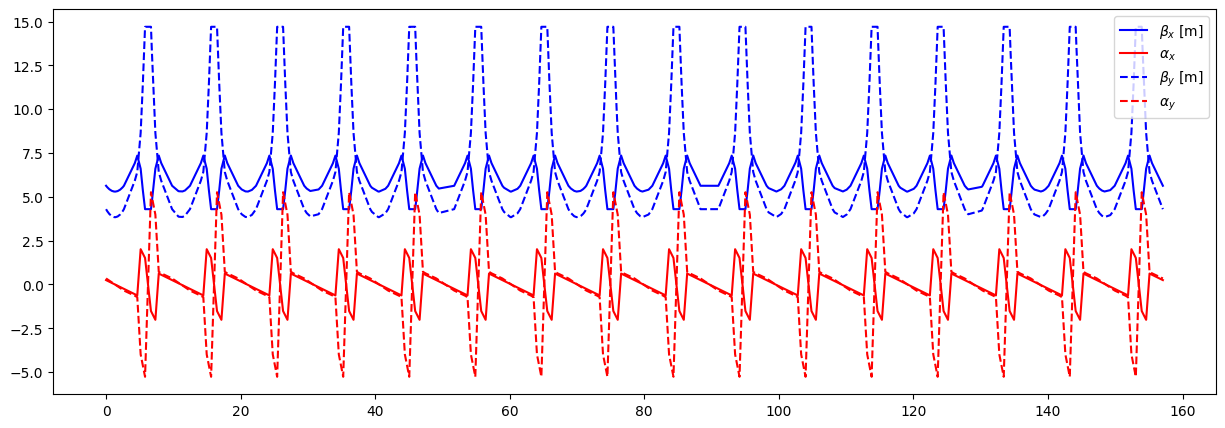

In [10]:
plt.figure(figsize=(15,5))
plt.plot(twiss_df['s'], twiss_df['betx'], label=r'$\beta_x$ [m]', c='blue')
plt.plot(twiss_df['s'], twiss_df['alfx'], label=r'$\alpha_x$', c='red')
plt.plot(twiss_df['s'], twiss_df['bety'], label=r'$\beta_y$ [m]', c='blue', ls='--')
plt.plot(twiss_df['s'], twiss_df['alfy'], label=r'$\alpha_y$', c='red', ls='--')
plt.legend()

### Exercise 3: matching the tunes

In PSB, all the focusing quadrupoles are powered in series which means all of them can have the same strength. Same applies for the defocusing quadrupoles. The strength of the focusing quadrupoles is conventionally named as "kbrqf" while for the defocusing "kbrqd". 

Xsuite has algorithms to calculate the quadrupole strengths in order to achieve our desired optics constrains (for example a certain tune, an upper limit for the beta-function etc.). This process is known as optics matching. 

In this exercise, vary the quadrupole strength to match the transverse betatron tunes to $(Q_x,Q_y)=(4.17,4.23)$ using the `line.match` command of Xsuite. 

In [7]:
# The initial lattice gives the following tunes
print('Qx = ', twiss.qx)
print('Qy = ', twiss.qy)

Qx =  4.399999999821676
Qy =  4.45000000057853


In [9]:
# We re-twiss the latice
twiss_after = line.twiss()
twiss_after_df = twiss_after.to_pandas()
print('Horizontal tune after the matching Qx = ', twiss_after.qx)
print('Vertical tune after the matching Qy = ', twiss_after.qy)

Horizontal tune after the matching Qx =  4.399999999821676
Vertical tune after the matching Qy =  4.45000000057853


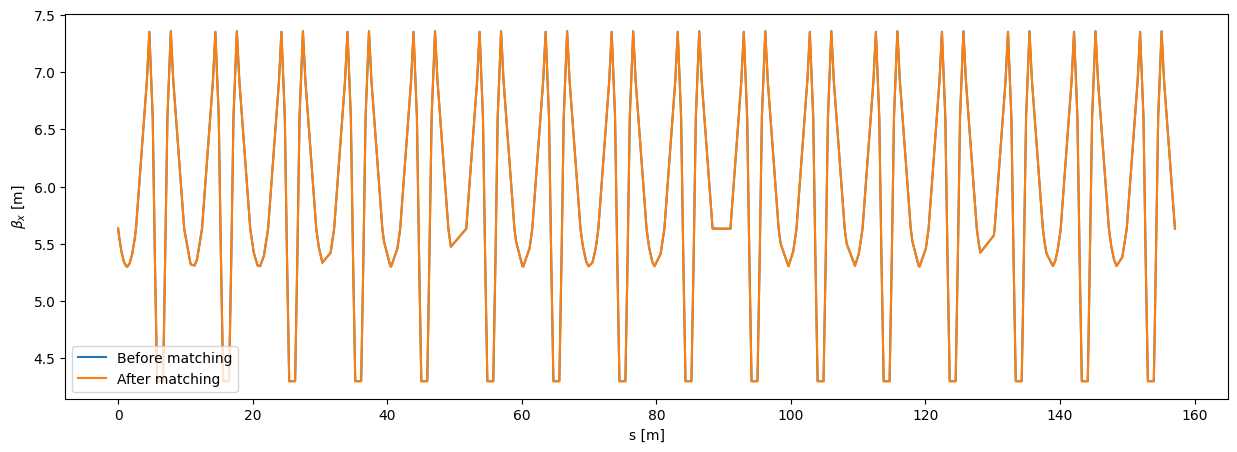

In [10]:
# The beta-function changed in the new configuration of the quadrupoles
plt.figure(figsize=(15,5))
plt.plot(twiss_df['s'], twiss_df['betx'], label='Before matching')
plt.plot(twiss_after_df['s'], twiss_after_df['betx'], label='After matching')
plt.xlabel('s [m]')
plt.ylabel(r'$\beta_x$ [m]')
plt.legend()

In [11]:
# Here we vary the strength of the sextupoles to reach the target chromaticity 
# Having a single knob for our sextupoles we can target the chromaticity only in one plane...
line.match(
      vary=[
            xt.Vary('kbr1xnoh0', step=1e-4, tag='sext'),
        
      ],
      targets = [
                  xt.Target('dqy', 0, tol=1e-5),
      ]
)

                                             
Optimize - start penalty: 7.15                              
Matching: model call n. 4 penalty = 4.0377e-08              
Optimize - end penalty:  4.03766e-08                            


In [12]:
twiss = line.twiss()
print( 'dqx = ', twiss.dqx, ' dqy = ', twiss.dqy)

dqx =  -6.915867911505558  dqy =  -4.037659095956769e-08


In [13]:
kl=line.vars['kbr1xnoh0']._value
current=kl*251.8
print('Sextupole strength kbr1xnoh0 = ', kl, ' corresponding to a current of ', current, ' A')

Sextupole strength kbr1xnoh0 =  0.3604363142712699  corresponding to a current of  90.75786393350576  A


#### Try at home: iteratively match the lattice to Qx from 4.1 to 4.4 by keeping the Qy constant at 4.23 and plot the beta_x function at the beginning of the lattice as a function of Qx. How much do the optics change for the different horizontal tunes?

### Exercise 4: tracking in the PSB

- Generate a matched Guassian distribution of $1000$ particles and track it for one turn in the PSB lattice. Plot the particle trajectories along the ring in the vertical plane (y). 

- Track the same distribution for $1000$ turns (without saving the particle state at all PSB elements). How long did it take?


In [37]:
# Xsuite tracks in 3D, so we need to add a voltage to the RF cavity to simulate the longitudinal motion
line.element_refs['br.c02'].voltage = 0.008*1e6
print('Constant voltage = 8 kV added to the dummy RF.')

particles = xp.generate_matched_gaussian_bunch(num_particles=1000,
                                total_intensity_particles=1e10,
                                nemitt_x=1e-6, nemitt_y=1e-6, sigma_z=10,
                                particle_ref=line.particle_ref,
                                line=line
                                )

Constant voltage = 8 kV added to the dummy RF.
*** Maximum RMS bunch length 24.692096598476237m.


/Users/fasvesta/miniforge3/envs/xsuite_env/lib/python3.11/site-packages/scipy/integrate/_quadpack_py.py:1264: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  quad_r = quad(f, low, high, args=args, full_output=self.full_output,


... distance to target bunch length: -1.0000e+01
... distance to target bunch length: 1.4070e+01
... distance to target bunch length: 1.0280e+01
... distance to target bunch length: 7.1279e-01
... distance to target bunch length: -6.6033e-02
... distance to target bunch length: -6.8977e-04
... distance to target bunch length: 1.3118e-08
... distance to target bunch length: -5.5007e-05
--> Bunch length: 10.000000013117543
--> Emittance: 0.23228237146654518


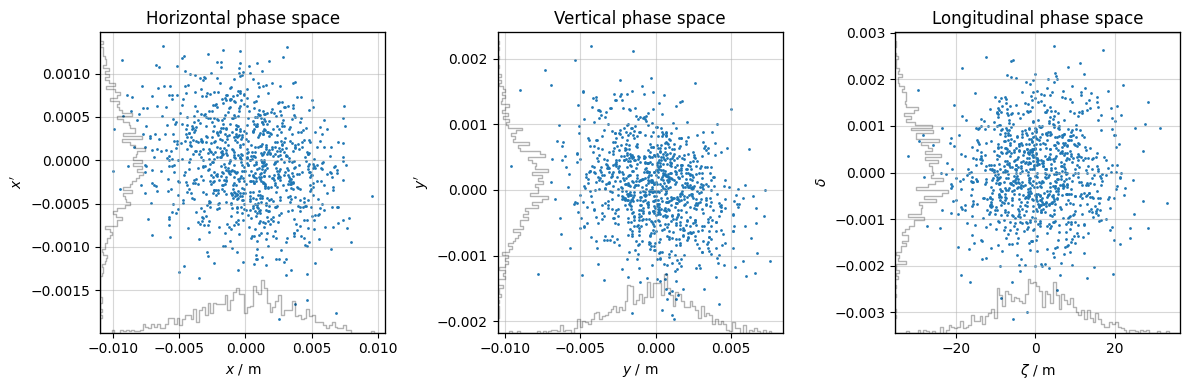

In [38]:
plot = xplt.PhaseSpacePlot(particles)
plot.fig.tight_layout()

In [39]:
# Tracking for one turn but saving the particle distribution at all PSB elements
line.track(particles, num_turns=1, turn_by_turn_monitor='ONE_TURN_EBE') # to save in all elements

Text(0, 0.5, 'y [mm]')

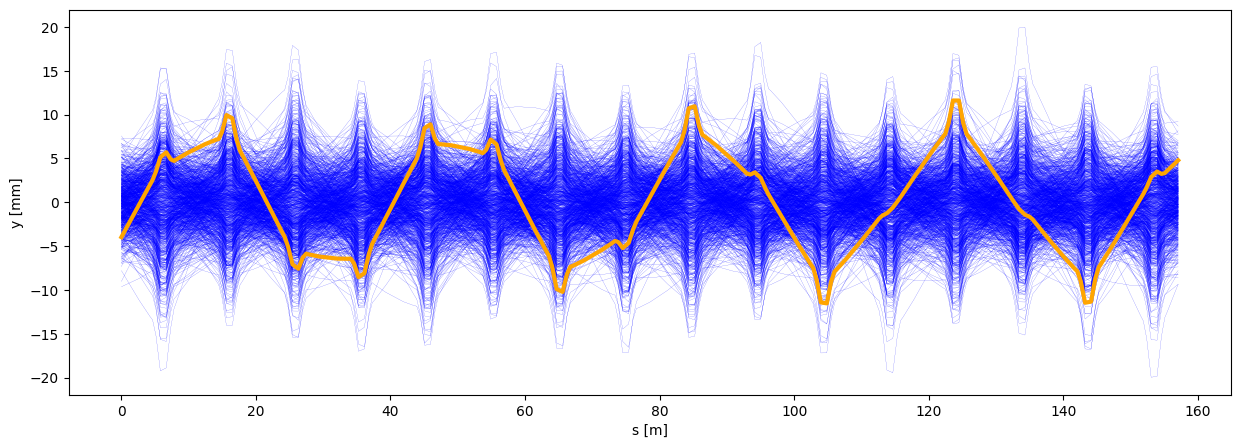

In [40]:
# Plotting the particle trajectories in y
plt.figure(figsize=(15,5))
for i in range(1000):
    plt.plot(line.record_last_track.s[0], line.record_last_track.y[i]*1e3, '-', lw=0.1, c='blue')
plt.plot(line.record_last_track.s[0], line.record_last_track.y[0]*1e3, '-', lw=3, c='orange', label='Single particle trajectory')
plt.xlabel('s [m]')
plt.ylabel('y [mm]')

In [ ]:
import time
start = time.time()
line.track(particles, num_turns=1000)
end = time.time()
print('Tracking time for 1000 turns = ', end-start, ' seconds')
print('Tracking time per turn per particle = ', (end-start)/(1000*1000)*1e6, 'microseconds')

### Exercise 5: reconstruct tune from turn-by-turn data

- Match the PSB lattice to the working point of $(Q_x, Q_y)=(4.42, 4.23)$  and track a single particle for 1000 turns. 

- Do an FFT analysis to calculate the tune from the turn-by-turn data 

- Add some noise to the TbT beam position and re-do the FFT.


In [ ]:
# The MAD-X sequence is at the psb/psb.seq file. The aperture of each element is defined at psb/psb_aperture.dbx
mad = Madx()
mad.options.echo = False # to not print the stdout of MAD-X  
mad.chdir('psb')
mad.call('psb_flat_bottom.madx') # loads the PSB sequence, aperture, etc. in MAD-X
line= xt.Line.from_madx_sequence(mad.sequence['psb1'],
                                 deferred_expressions=True,
                                 allow_thick=True)

# We need to add a reference particle for the twiss calculation (mass, energy)
line.particle_ref=xp.Particles(mass0=xp.PROTON_MASS_EV,gamma0=mad.sequence.psb1.beam.gamma)
print('Reference particle added at gamma0=%s.'%(mad.sequence.psb1.beam.gamma))

# Xsuite tracks in 3D, so we need to add a voltage to the RF cavity to simulate the longitudinal motion
line.element_refs['br.c02'].voltage = 0.008*1e6
print('Constant voltage = 8 kV added to the dummy RF.')

Qx0 = 4.42
Qy0 = 4.23
# Here we vary the strength of the quadrupoles (two knobs) to reach the target tunes (two constraints)
# The matching process is not always possible..
line.match(
      vary=[
            xt.Vary('kbrqf', step=1e-8),
            xt.Vary('kbrqd', step=1e-8),
      ],
      targets = [
                  xt.Target('qx', Qx0, tol=1e-5),
                  xt.Target('qy', Qy0, tol=1e-5)
      ]
)

twiss = line.twiss()
twiss_df = twiss.to_pandas()


  ++++++++++++++++++++++++++++++++++++++++++++
  +     MAD-X 5.09.03  (64 bit, Darwin)      +
  + Support: mad@cern.ch, http://cern.ch/mad +
  + Release   date: 2024.04.25               +
  + Execution date: 2026.04.20 15:26:29      +
  ++++++++++++++++++++++++++++++++++++++++++++
++++++ info: seqedit - number of elements installed:  0
++++++ info: seqedit - number of elements moved:      0
++++++ info: seqedit - number of elements removed:    0
++++++ info: seqedit - number of elements replaced:   0
++++++ info: seqedit - number of elements installed:  1
++++++ info: seqedit - number of elements moved:      0
++++++ info: seqedit - number of elements removed:    0
++++++ info: seqedit - number of elements replaced:   0


Converting sequence "psb1":   0%|          | 0/530 [00:00<?, ?it/s]

Reference particle added at gamma0=1.1705262269290748.
Constant voltage = 8 kV added to the dummy RF.
                                             
Optimize - start penalty: 2.209                             
Matching: model call n. 9 penalty = 2.2082e-06              
Optimize - end penalty:  2.20815e-06                            


In [ ]:
# Built a set of three particles with different y coordinates
# (context and particle_ref are taken from the line)
particles = line.build_particles(x = [0.5e-3], y=[1e-3]) # single particle at x=0.5 mm, y=1 mm

num_turns = 1000
line.track(particles, num_turns=num_turns, turn_by_turn_monitor=True)

x_tbt = line.record_last_track.x[0]
y_tbt = line.record_last_track.y[0]

Text(0, 0.5, 'Amplitude [mm]')

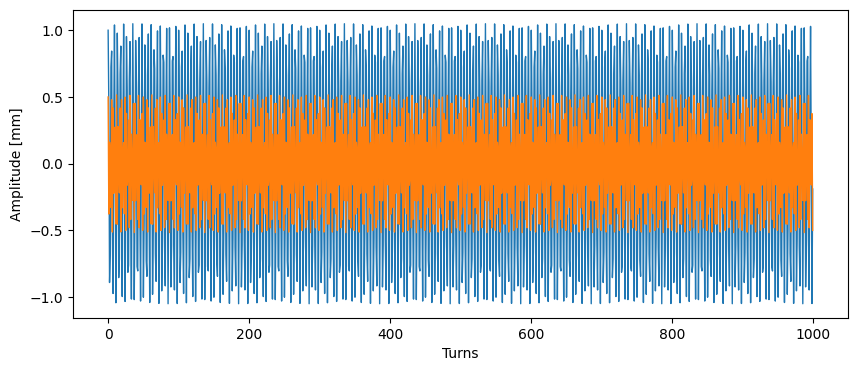

In [ ]:
# Plotting turn-by-turn data for the two planes
plt.figure(figsize=(10,4))
plt.plot(y_tbt*1e3, linewidth=1)
plt.plot(x_tbt*1e3, linewidth=1)
plt.xlabel('Turns')
plt.ylabel('Amplitude [mm]')

In [ ]:
# spectrum using fft
data = np.array(y_tbt) # focusing only in the y-plane
n = len(data)
spectrum=np.fft.rfft(data)
freqs = np.fft.rfftfreq(n, d=1) # frequencies in units of 1/turns
tune = freqs[np.where(np.max(spectrum) == spectrum)[0]]

/var/folders/8j/pt0rsctj3m39t30znf2xhw0w0000gq/T/ipykernel_65238/310764131.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ax.stem(freqs, abs(spectrum/np.max(spectrum)), label='fft ($q=%1.3f$)'%tune)


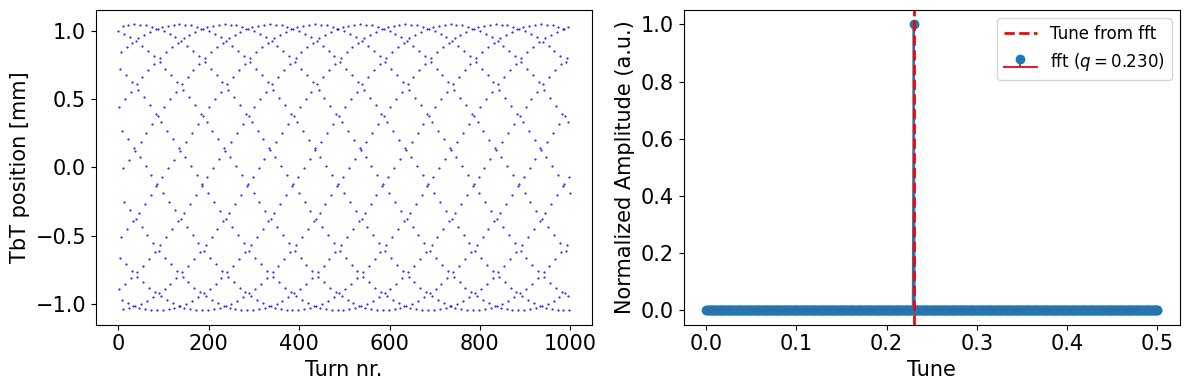

In [ ]:
f,axs = plt.subplots(1,2,figsize=(12,4))
fontsize=15

ax = axs[0]
ax.set_xlabel('Turn nr.', fontsize=fontsize)
ax.set_ylabel('TbT position [mm]', fontsize=fontsize)
ax.tick_params(labelsize=fontsize)
ax.plot(data*1e3, '.', ms=1.0, c='blue')

ax = axs[1]
ax.set_xlabel('Tune', fontsize=fontsize)
ax.set_ylabel('Normalized Amplitude (a.u.)', fontsize=fontsize)
ax.tick_params(labelsize=fontsize)
ax.stem(freqs, abs(spectrum/np.max(spectrum)), label='fft ($q=%1.3f$)'%tune)
ax.plot(freqs, abs(spectrum/np.max(spectrum)))
ax.axvline(tune, color='red', lw=2, ls='--', label='Tune from fft')
ax.legend(loc=0, fontsize=fontsize-3)
# ax.set_xlim(0.4,0.5)

f.tight_layout()
plt.show()


In [ ]:
# Adding errors in the turn-by-turn data
data2 = data + 1e-3*np.random.randn(len(data)) # noise

# spectrum using fft
n = len(data2)
spectrum=np.fft.rfft(data2)
freqs = np.fft.rfftfreq(n, d=1) # frequencies in units of 1/turns
tune = freqs[np.where(np.max(spectrum) == spectrum)[0]]


/var/folders/8j/pt0rsctj3m39t30znf2xhw0w0000gq/T/ipykernel_65238/3416131016.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ax.stem(freqs, abs(spectrum/np.max(spectrum)), label='fft ($q=%1.3f$)'%tune)


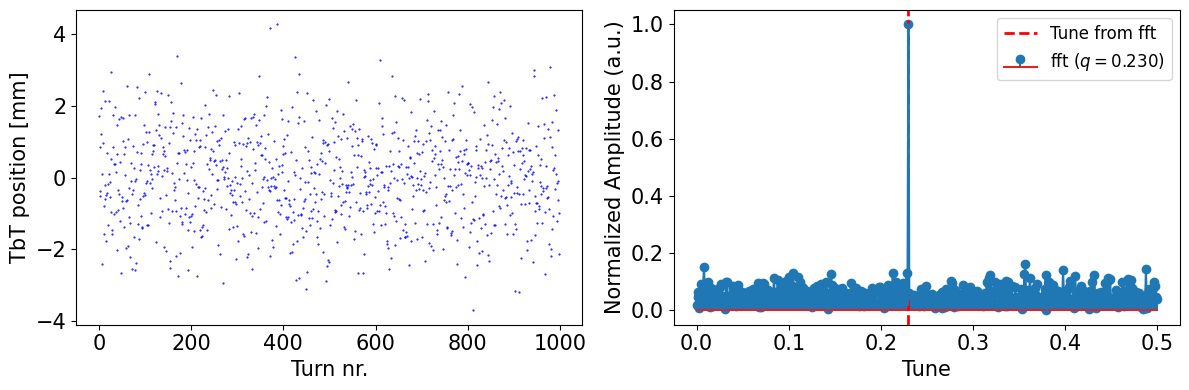

In [ ]:
f,axs = plt.subplots(1,2,figsize=(12,4))
fontsize=15

ax = axs[0]
ax.set_xlabel('Turn nr.', fontsize=fontsize)
ax.set_ylabel('TbT position [mm]', fontsize=fontsize)
ax.tick_params(labelsize=fontsize)
ax.plot(data2*1e3, '.', ms=1.0, c='blue')

ax = axs[1]
ax.set_xlabel('Tune', fontsize=fontsize)
ax.set_ylabel('Normalized Amplitude (a.u.)', fontsize=fontsize)
ax.tick_params(labelsize=fontsize)
ax.stem(freqs, abs(spectrum/np.max(spectrum)), label='fft ($q=%1.3f$)'%tune)
ax.axvline(tune, color='red', lw=2, ls='--', label='Tune from fft')
ax.plot(freqs, abs(spectrum/np.max(spectrum)))
ax.legend(loc=0, fontsize=fontsize-3)
# ax.set_xlim(0.4,0.5)

f.tight_layout()
plt.show()


### Exercise 6: reconstruct tune from turn-by-turn data

- Match the PSB lattice to the working point of $(Q_x, Q_y)=(4.42, 4.23)$  

- Add space charge using the approcimation for Gaussian beams

- Track the same single particle for 5000 turns. 

- Do an FFT analysis to calculate the tune from the turn-by-turn data 

- Repeat, adapting the beam parameters; What do you observe on the particle tune?


In [ ]:
# The MAD-X sequence is at the psb/psb.seq file. The aperture of each element is defined at psb/psb_aperture.dbx
mad = Madx()
mad.options.echo = False # to not print the stdout of MAD-X  
mad.chdir('psb')
mad.call('psb_flat_bottom.madx') # loads the PSB sequence, aperture, etc. in MAD-X
line= xt.Line.from_madx_sequence(mad.sequence['psb1'],
                                 deferred_expressions=True,
                                 allow_thick=True)

# We need to add a reference particle for the twiss calculation (mass, energy)
line.particle_ref=xp.Particles(mass0=xp.PROTON_MASS_EV,gamma0=mad.sequence.psb1.beam.gamma)
print('Reference particle added at gamma0=%s.'%(mad.sequence.psb1.beam.gamma))

# Xsuite tracks in 3D, so we need to add a voltage to the RF cavity to simulate the longitudinal motion
line.element_refs['br.c02'].voltage = 0.008*1e6
print('Constant voltage = 8 kV added to the dummy RF.')

Qx0 = 4.42
Qy0 = 4.23
# Here we vary the strength of the quadrupoles (two knobs) to reach the target tunes (two constraints)
# The matching process is not always possible..
line.match(
      vary=[
            xt.Vary('kbrqf', step=1e-8),
            xt.Vary('kbrqd', step=1e-8),
      ],
      targets = [
                  xt.Target('qx', Qx0, tol=1e-5),
                  xt.Target('qy', Qy0, tol=1e-5)
      ]
)
twiss = line.twiss()
twiss_df = twiss.to_pandas()


  ++++++++++++++++++++++++++++++++++++++++++++
  +     MAD-X 5.09.03  (64 bit, Darwin)      +
  + Support: mad@cern.ch, http://cern.ch/mad +
  + Release   date: 2024.04.25               +
  + Execution date: 2026.04.20 15:28:46      +
  ++++++++++++++++++++++++++++++++++++++++++++
++++++ info: seqedit - number of elements installed:  0
++++++ info: seqedit - number of elements moved:      0
++++++ info: seqedit - number of elements removed:    0
++++++ info: seqedit - number of elements replaced:   0
++++++ info: seqedit - number of elements installed:  1
++++++ info: seqedit - number of elements moved:      0
++++++ info: seqedit - number of elements removed:    0
++++++ info: seqedit - number of elements replaced:   0


Converting sequence "psb1":   0%|          | 0/530 [00:00<?, ?it/s]

Reference particle added at gamma0=1.1705262269290748.
Constant voltage = 8 kV added to the dummy RF.
                                             
Optimize - start penalty: 2.209                             
Matching: model call n. 9 penalty = 2.2082e-06              
Optimize - end penalty:  2.20815e-06                            


In [ ]:
# Give the beam parameters for the space charge calculation
nemitt_x=1e-6
nemitt_y=1e-6
bunch_intensity=30e10
sigma_z=17

num_spacecharge_interactions = 160 
tol_spacecharge_position = 1e-3

mode = 'frozen'

# Install spacecharge interactions (frozen) 

lprofile = xf.LongitudinalProfileQGaussian(
        number_of_particles=bunch_intensity,
        sigma_z=sigma_z,
        z0=0.,
        q_parameter=1.)

xf.install_spacecharge_frozen(line=line,
                  particle_ref=line.particle_ref,
                   longitudinal_profile=lprofile,
                   nemitt_x=nemitt_x, nemitt_y=nemitt_y,
                   sigma_z=sigma_z,
                   num_spacecharge_interactions=num_spacecharge_interactions)

*** Maximum RMS bunch length 24.69209659847623m.
... distance to target bunch length: -1.7000e+01
... distance to target bunch length: 7.0701e+00
... distance to target bunch length: 6.3354e+00
... distance to target bunch length: 1.4910e+00
... distance to target bunch length: -2.6126e+00
... distance to target bunch length: 2.2608e-01
... distance to target bunch length: -7.6580e-03
... distance to target bunch length: 1.1623e-04
... distance to target bunch length: 5.7891e-08
... distance to target bunch length: -7.2992e-05
--> Bunch length: 17.000000057891004
--> Emittance: 0.6154846995850753


Creating spacecharge elements:   0%|          | 0/160 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/530 [00:00<?, ?it/s]

Locate insertion points:   0%|          | 0/160 [00:00<?, ?it/s]

Inserting elements:   0%|          | 0/160 [00:00<?, ?it/s]

In [ ]:
particles = line.build_particles(x = [0.5e-3], y=[1e-3]) # single particle at x=0.5 mm, y=1 mm

num_turns = 5000
line.track(particles, num_turns=num_turns, turn_by_turn_monitor=True)

x_tbt = line.record_last_track.x[0]
y_tbt = line.record_last_track.y[0]
px_tbt = line.record_last_track.px[0]
py_tbt = line.record_last_track.py[0]

(1.0, 1000.0)

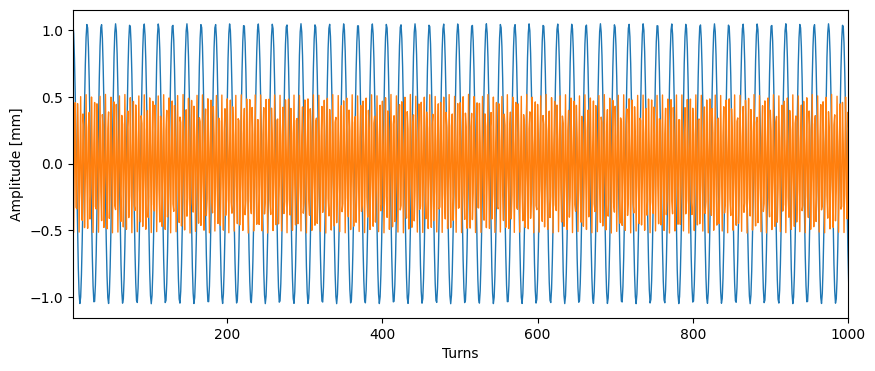

In [ ]:
# Plotting turn-by-turn data for the two planes
plt.figure(figsize=(10,4))
plt.plot(y_tbt*1e3, linewidth=1)
plt.plot(x_tbt*1e3, linewidth=1)
plt.xlabel('Turns')
plt.ylabel('Amplitude [mm]')
plt.xlim(1,1000)

/var/folders/8j/pt0rsctj3m39t30znf2xhw0w0000gq/T/ipykernel_65238/2412980289.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc=0, fontsize=fontsize-3)


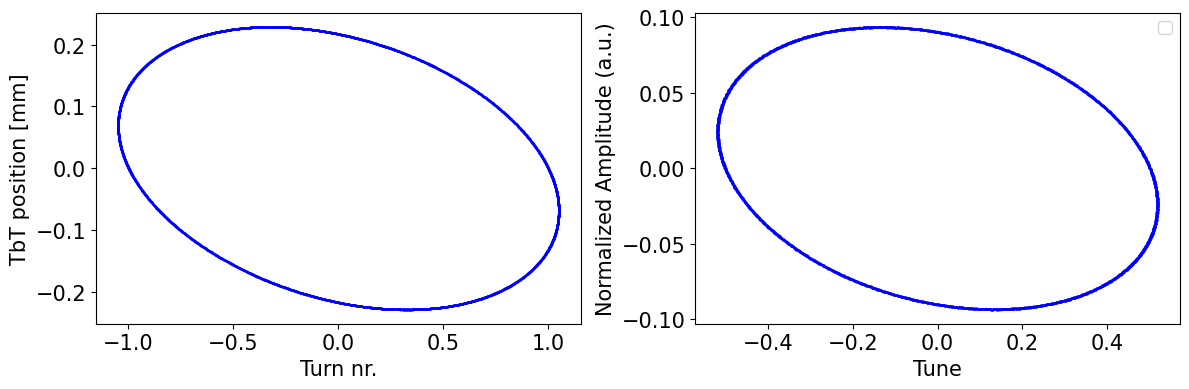

In [ ]:
# Plotting phase space for the two planes

f,axs = plt.subplots(1,2,figsize=(12,4))
fontsize=15

ax = axs[0]
ax.set_xlabel('Turn nr.', fontsize=fontsize)
ax.set_ylabel('TbT position [mm]', fontsize=fontsize)
ax.tick_params(labelsize=fontsize)
ax.plot(y_tbt*1e3,py_tbt*1e3, '.', ms=1.0, c='blue')

ax = axs[1]
ax.set_xlabel('Tune', fontsize=fontsize)
ax.set_ylabel('Normalized Amplitude (a.u.)', fontsize=fontsize)
ax.tick_params(labelsize=fontsize)
ax.plot(x_tbt*1e3,px_tbt*1e3, '.', ms=1.0, c='blue')
ax.legend(loc=0, fontsize=fontsize-3)
# ax.set_xlim(0.4,0.5)

f.tight_layout()
plt.show()


In [ ]:
# spectrum using fft
data = np.array(y_tbt) # focusing only in the y-plane
n = len(data)
spectrum=np.fft.rfft(data)
freqs = np.fft.rfftfreq(n, d=1) # frequencies in units of 1/turns
tune = freqs[np.where(np.max(abs(spectrum)) == abs(spectrum))[0]]


/var/folders/8j/pt0rsctj3m39t30znf2xhw0w0000gq/T/ipykernel_65238/310764131.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ax.stem(freqs, abs(spectrum/np.max(spectrum)), label='fft ($q=%1.3f$)'%tune)


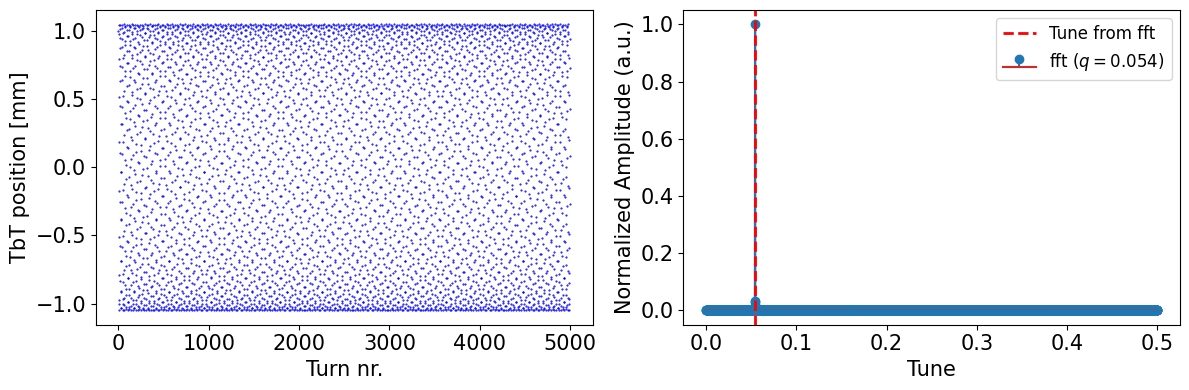

In [ ]:
f,axs = plt.subplots(1,2,figsize=(12,4))
fontsize=15

ax = axs[0]
ax.set_xlabel('Turn nr.', fontsize=fontsize)
ax.set_ylabel('TbT position [mm]', fontsize=fontsize)
ax.tick_params(labelsize=fontsize)
ax.plot(data*1e3, '.', ms=1.0, c='blue')

ax = axs[1]
ax.set_xlabel('Tune', fontsize=fontsize)
ax.set_ylabel('Normalized Amplitude (a.u.)', fontsize=fontsize)
ax.tick_params(labelsize=fontsize)
ax.stem(freqs, abs(spectrum/np.max(spectrum)), label='fft ($q=%1.3f$)'%tune)
ax.plot(freqs, abs(spectrum/np.max(spectrum)))
ax.axvline(tune, color='red', lw=2, ls='--', label='Tune from fft')
ax.legend(loc=0, fontsize=fontsize-3)
# ax.set_xlim(0.4,0.5)

f.tight_layout()
plt.show()


### Exercise 7: particles on a resonance
- Match the PSB lattice to the working point of $(Q_x, Q_y)=(4.42, 4.23)$  

- Add space charge to the lattice simulating a full beam

- Track an ensemble of test particles for 5000 turns

- Plot their the phase space and calculate the tunes under space charge

- Include an error in the lattice and repeat the process

In [ ]:
# The MAD-X sequence is at the psb/psb.seq file. The aperture of each element is defined at psb/psb_aperture.dbx
mad = Madx()
mad.options.echo = False # to not print the stdout of MAD-X  
mad.chdir('psb')
mad.call('psb_flat_bottom.madx') # loads the PSB sequence, aperture, etc. in MAD-X
line= xt.Line.from_madx_sequence(mad.sequence['psb1'],
                                 deferred_expressions=True,
                                 allow_thick=True)

# We need to add a reference particle for the twiss calculation (mass, energy)
line.particle_ref=xp.Particles(mass0=xp.PROTON_MASS_EV,gamma0=mad.sequence.psb1.beam.gamma)
print('Reference particle added at gamma0=%s.'%(mad.sequence.psb1.beam.gamma))

# Xsuite tracks in 3D, so we need to add a voltage to the RF cavity to simulate the longitudinal motion
line.element_refs['br.c02'].voltage = 0.008*1e6
print('Constant voltage = 8 kV added to the dummy RF.')

Qx0 = 4.42
Qy0 = 4.23
# Here we vary the strength of the quadrupoles (two knobs) to reach the target tunes (two constraints)
# The matching process is not always possible..
line.match(
      vary=[
            xt.Vary('kbrqf', step=1e-8),
            xt.Vary('kbrqd', step=1e-8),
      ],
      targets = [
                  xt.Target('qx', Qx0, tol=1e-5),
                  xt.Target('qy', Qy0, tol=1e-5)
      ]
)
twiss = line.twiss()
twiss_df = twiss.to_pandas()


  ++++++++++++++++++++++++++++++++++++++++++++
  +     MAD-X 5.09.03  (64 bit, Darwin)      +
  + Support: mad@cern.ch, http://cern.ch/mad +
  + Release   date: 2024.04.25               +
  + Execution date: 2026.04.20 15:31:33      +
  ++++++++++++++++++++++++++++++++++++++++++++
++++++ info: seqedit - number of elements installed:  0
++++++ info: seqedit - number of elements moved:      0
++++++ info: seqedit - number of elements removed:    0
++++++ info: seqedit - number of elements replaced:   0
++++++ info: seqedit - number of elements installed:  1
++++++ info: seqedit - number of elements moved:      0
++++++ info: seqedit - number of elements removed:    0
++++++ info: seqedit - number of elements replaced:   0


Converting sequence "psb1":   0%|          | 0/530 [00:00<?, ?it/s]

Reference particle added at gamma0=1.1705262269290748.
Constant voltage = 8 kV added to the dummy RF.
                                             
Optimize - start penalty: 2.209                             
Matching: model call n. 9 penalty = 2.2082e-06              
Optimize - end penalty:  2.20815e-06                            


In [ ]:
# Give the beam parameters for the space charge calculation
nemitt_x=1e-6
nemitt_y=1e-6
bunch_intensity=30e10
sigma_z=17

num_spacecharge_interactions = 160 
tol_spacecharge_position = 1e-3

mode = 'frozen'

# Install spacecharge interactions (frozen) 

lprofile = xf.LongitudinalProfileQGaussian(
        number_of_particles=bunch_intensity,
        sigma_z=sigma_z,
        z0=0.,
        q_parameter=1.)

xf.install_spacecharge_frozen(line=line,
                  particle_ref=line.particle_ref,
                   longitudinal_profile=lprofile,
                   nemitt_x=nemitt_x, nemitt_y=nemitt_y,
                   sigma_z=sigma_z,
                   num_spacecharge_interactions=num_spacecharge_interactions)

line.build_tracker()

*** Maximum RMS bunch length 24.69209659847623m.
... distance to target bunch length: -1.7000e+01
... distance to target bunch length: 7.0701e+00
... distance to target bunch length: 6.3354e+00
... distance to target bunch length: 1.4910e+00
... distance to target bunch length: -2.6126e+00
... distance to target bunch length: 2.2608e-01
... distance to target bunch length: -7.6580e-03
... distance to target bunch length: 1.1623e-04
... distance to target bunch length: 5.7891e-08
... distance to target bunch length: -7.2992e-05
--> Bunch length: 17.000000057891004
--> Emittance: 0.6154846995850753


Creating spacecharge elements:   0%|          | 0/160 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/530 [00:00<?, ?it/s]

Locate insertion points:   0%|          | 0/160 [00:00<?, ?it/s]

Inserting elements:   0%|          | 0/160 [00:00<?, ?it/s]

In [ ]:
# generate grid of particles and track

x_norm, y_norm, _, _ = xp.generate_2D_polar_grid(
    theta_range=(0.001, np.pi/2-0.001),
    ntheta = 1,
    r_range = (0.1, 2),
    nr = 10)

particles = xp.build_particles(line=line, particle_ref=line.particle_ref,
                               x_norm=x_norm, y_norm=y_norm, delta=0,
                               nemitt_x=nemitt_x, nemitt_y=nemitt_y)

line.track(particles, num_turns=5000, turn_by_turn_monitor=True )


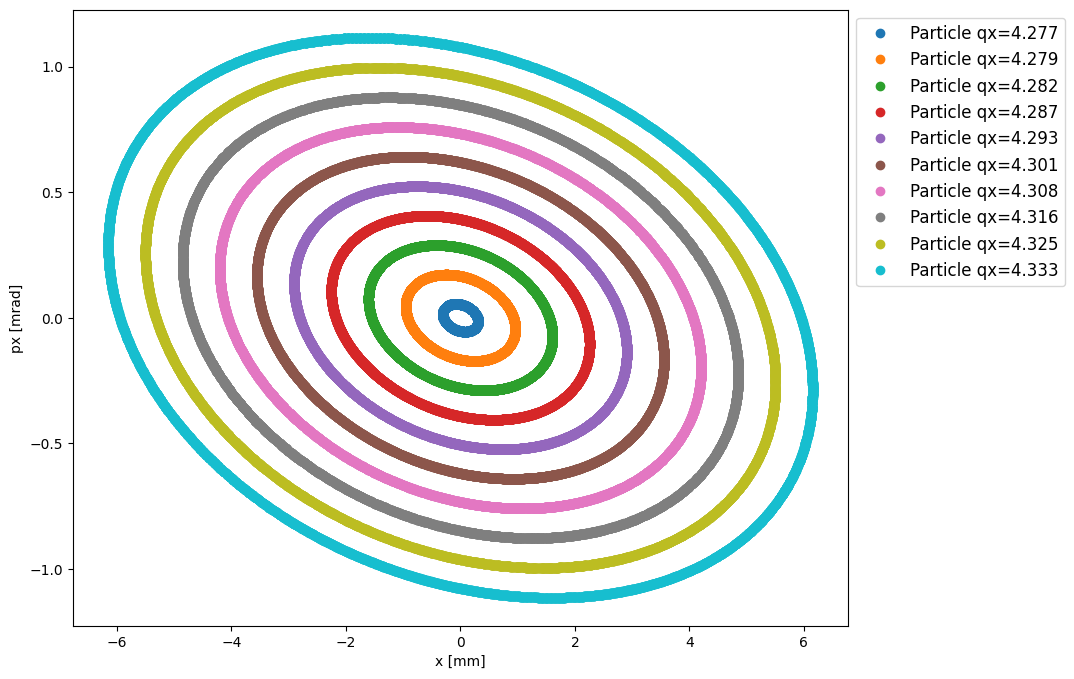

In [ ]:
data_x = np.array(line.record_last_track.x)
data_px = np.array(line.record_last_track.px)
# Plotting turn-by-turn data for the two planes

fig= plt.figure(figsize=(10,8))
qx=[]
for i in range(len(data_x)):
    qx.append(nafflib.get_tune(data_x[i]-np.mean(data_x[i])))
    plt.plot(data_x[i]*1e3,data_px[i]*1e3, 'o', label='Particle qx=%1.3f'%(qx[i]+4.))
plt.xlabel('x [mm]')
plt.ylabel('px [mrad]')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=fontsize-3)


In [ ]:
# adding an error in our lattice and re-doing the tracking 
line['br.bhz11'].knl[2] = 0.45

x_norm, y_norm, _, _ = xp.generate_2D_polar_grid(
    theta_range=(0.001, np.pi/2-0.001),
    ntheta = 1,
    r_range = (0.12, 2),
    nr = 10)

particles = xp.build_particles(line=line, particle_ref=line.particle_ref,
                               x_norm=x_norm, y_norm=y_norm, delta=0,
                               nemitt_x=nemitt_x, nemitt_y=nemitt_y)

line.track(particles, num_turns=2000, turn_by_turn_monitor=True )

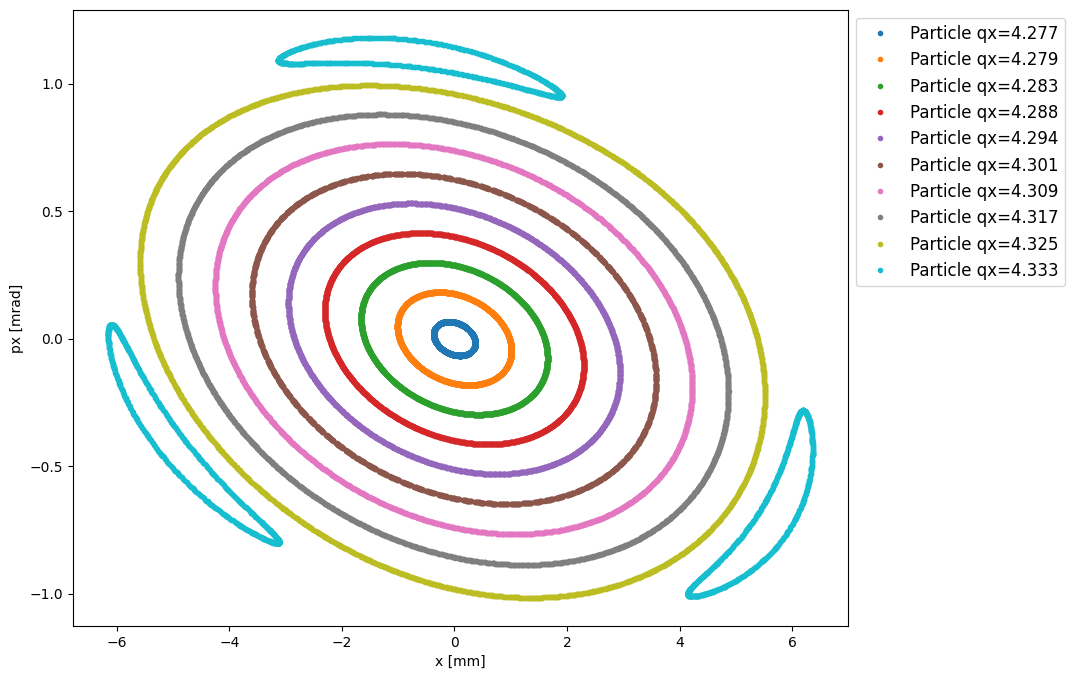

In [ ]:
data_x = np.array(line.record_last_track.x)
data_px = np.array(line.record_last_track.px)
# Plotting turn-by-turn data for the two planes

fig= plt.figure(figsize=(10,8))
qx=[]
for i in range(len(data_x)):
    qx.append(nafflib.get_tune(data_x[i]-np.mean(data_x[i])))
    plt.plot(data_x[i]*1e3,data_px[i]*1e3, '.', label='Particle qx=%1.3f'%(qx[i]+4.))
plt.xlabel('x [mm]')
plt.ylabel('px [mrad]')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=fontsize-3)


### Exercise 8: Manipulate initial emittance

The transverse painting is a technique to uniformly fill the phase space in order to intentionally make the beam larger and more uniform in order to reduce the space charge. 

In the PSB, the transverse painting is performed by applying an offset between the injected beam and the closed orbit. This offset can be constant or it can change turn-by-turn (remember in the PSB we can inject over many turns).

In this exercise, we will implement a transverse painting scheme for the PSB. 

In [ ]:
# First we load and match the PSB lattice to a certain working point 
mad = Madx()
mad.options.echo = False
mad.chdir('psb')
mad.call('psb_flat_bottom.madx')
line= xt.Line.from_madx_sequence(mad.sequence['psb1'],deferred_expressions=True,allow_thick=True)
line.particle_ref=xp.Particles(mass0=xp.PROTON_MASS_EV,gamma0=mad.sequence.psb1.beam.gamma)
line.element_refs['br.c02'].voltage = 0.008*1e6
Qx0 = 4.17
Qy0 = 4.23
line.match(vary=[xt.Vary('kbrqf', step=1e-8),xt.Vary('kbrqd', step=1e-8)],
           targets = [xt.Target('qx', Qx0, tol=1e-5),xt.Target('qy', Qy0, tol=1e-5)])
line.element_refs['br.c02'].voltage = 0.008*1e6 # for the tracking later


  ++++++++++++++++++++++++++++++++++++++++++++
  +     MAD-X 5.09.03  (64 bit, Darwin)      +
  + Support: mad@cern.ch, http://cern.ch/mad +
  + Release   date: 2024.04.25               +
  + Execution date: 2026.04.20 15:35:05      +
  ++++++++++++++++++++++++++++++++++++++++++++
++++++ info: seqedit - number of elements installed:  0
++++++ info: seqedit - number of elements moved:      0
++++++ info: seqedit - number of elements removed:    0
++++++ info: seqedit - number of elements replaced:   0
++++++ info: seqedit - number of elements installed:  1
++++++ info: seqedit - number of elements moved:      0
++++++ info: seqedit - number of elements removed:    0
++++++ info: seqedit - number of elements replaced:   0


Converting sequence "psb1":   0%|          | 0/530 [00:00<?, ?it/s]

                                             
Optimize - start penalty: 3.183                             
Matching: model call n. 9 penalty = 4.3539e-05              
Optimize - end penalty:  4.35394e-05                            


In [ ]:
# The PSB lattice in the MAD-X sequence starts at the beggining of the first sector (out of the 16 sectors). 
# The injection foil is in the middle of the straight section of the first sector.
# To be precise we shift the start of our lattice to the foil (bi1.tstr1l1).
line.discard_tracker() # We need to discard the tracker to edit the line
line.cycle(name_first_element = 'bi1.tstr1l1', inplace=True)
line.build_tracker()
print('Changed line starting point to bi1.tstr1l1 (foil).')

Changed line starting point to bi1.tstr1l1 (foil).


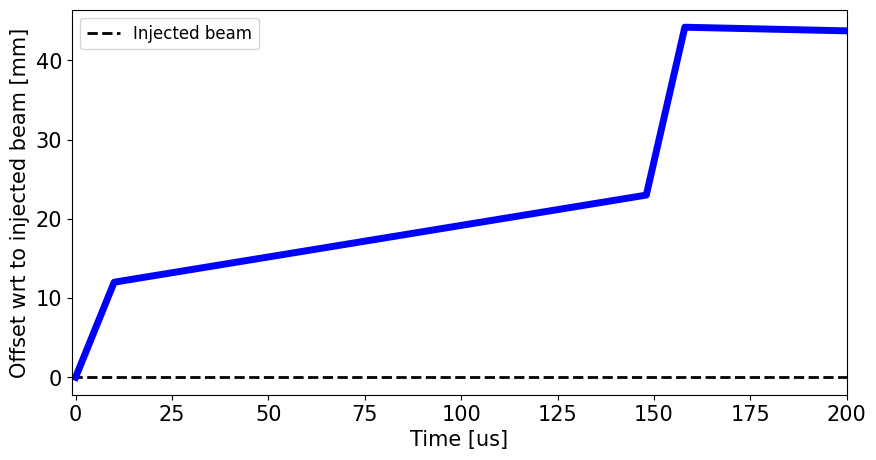

In [ ]:
# Here we will generate the shift in the closed orbit or the painting functions
# The function that is defined here is an ISOLDE-like painting
# We can change these functions however we like
p = {}
p['KSW_time_sec'] =         np.array([ 0.0e-6,  10e-6,  148e-6,    158e-6,  1000e-6]) # time in seconds, 1e-6 s is approximately 1 turn in the PSB
p['KSW_bump_amplitude_m'] = np.array([-35e-3,  -23e-3,  -12e-3,    9.2e-3,      0.0]) # the amplitude of the bump in meters

f,ax = plt.subplots(1,1,figsize=(10,5))
fontsize=15
ax.set_xlabel('Time [us]', fontsize=fontsize)
ax.set_ylabel('Offset wrt to injected beam [mm]', fontsize=fontsize)
ax.tick_params(labelsize=fontsize)

ax.axhline(0, color='black', ls='--', lw=2.0, label='Injected beam')
ax.plot(p['KSW_time_sec']*1e6, (p['KSW_bump_amplitude_m']-p['KSW_bump_amplitude_m'][0])*1e3, '-', lw=5, color='blue')

ax.set_xlim(-1, 200)
ax.legend(loc=0, fontsize=fontsize-3)

In [ ]:
# We will add the painting functions to the line

# the maximum bump amplitude in meters
X_BUMP = -3.5000000000e-02

# The corresponding strengths of the kickers that produce the bump
kbi1ksw1l40 = 5.1720959073e-03   
kbi1ksw2l10 = 1.3941261670e-02   
kbi1ksw16l10 = 1.6031186470e-02   
kbi1ksw16l40 = 3.7937180185e-03

# the length of the kickers
ksw_length = 0.37 # m, 

# Adding the painting function to these parameters
kbi1ksw1l4 = (-1)*p['KSW_bump_amplitude_m']/X_BUMP*kbi1ksw1l40*ksw_length
kbi1ksw2l1 = (-1)*p['KSW_bump_amplitude_m']/X_BUMP*kbi1ksw2l10*ksw_length
kbi1ksw16l1 = (-1)*p['KSW_bump_amplitude_m']/X_BUMP*kbi1ksw16l10*ksw_length
kbi1ksw16l4 = (-1)*p['KSW_bump_amplitude_m']/X_BUMP*kbi1ksw16l40*ksw_length

# Creating functions over time
line.functions['fun_kbiksw1l4'] = xd.FunctionPieceWiseLinear(x=p['KSW_time_sec'], y=kbi1ksw1l4)
line.functions['fun_kbiksw2l1'] = xd.FunctionPieceWiseLinear(x=p['KSW_time_sec'], y=kbi1ksw2l1)
line.functions['fun_kbiksw16l1'] = xd.FunctionPieceWiseLinear(x=p['KSW_time_sec'], y=kbi1ksw16l1)
line.functions['fun_kbiksw16l4'] = xd.FunctionPieceWiseLinear(x=p['KSW_time_sec'], y=kbi1ksw16l4)

# Assigning the functions to the knobs
line.vars['kbi1ksw1l4'] = line.functions.fun_kbiksw1l4(line.vars['t_turn_s'])
line.vars['kbi1ksw2l1'] = line.functions.fun_kbiksw2l1(line.vars['t_turn_s'])
line.vars['kbi1ksw16l1'] = line.functions.fun_kbiksw16l1(line.vars['t_turn_s'])
line.vars['kbi1ksw16l4'] = line.functions.fun_kbiksw16l4(line.vars['t_turn_s'])
print('Knobs built to control KSW bump.')
print('Variable "on_painting_bump" added to control KSW bump.')
print('Time dependence added to kbi1ksw1l4, kbi1ksw2l1, kbi1ksw16l1 and kbi1ksw16l4.')

Knobs built to control KSW bump.
Variable "on_painting_bump" added to control KSW bump.
Time dependence added to kbi1ksw1l4, kbi1ksw2l1, kbi1ksw16l1 and kbi1ksw16l4.


In [ ]:
print('Twissing.')
tw = line.twiss()
#tw = line.twiss(co_search_at='psb1$start') # closed orbit at PSB start, otherwise need to give co_guess (xtrack 0.52.0)
co_x_at_foil = tw['x', 'bi1.tstr1l1']
co_y_at_foil = tw['y', 'bi1.tstr1l1']
print('Closed orbit at foil: x = %s m, y = %s m.'%(co_x_at_foil, co_y_at_foil))

Twissing.
Closed orbit at foil: x = -0.04167897942869534 m, y = 6.17824042557578e-22 m.


In [ ]:
n_part = 20000
particles2inject = xp.generate_matched_gaussian_bunch(n_part,
                        total_intensity_particles=1e10,
                        nemitt_x=1e-6, nemitt_y=1e-6, sigma_z=10,
                        particle_ref=line.particle_ref,
                        line=line
                        )

*** Maximum RMS bunch length 24.692096598476233m.


/Users/fasvesta/miniforge3/envs/xsuite_env/lib/python3.11/site-packages/scipy/integrate/_quadpack_py.py:1264: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  quad_r = quad(f, low, high, args=args, full_output=self.full_output,


... distance to target bunch length: -1.0000e+01
... distance to target bunch length: 1.4070e+01
... distance to target bunch length: 1.0280e+01
... distance to target bunch length: 7.1279e-01
... distance to target bunch length: -6.6033e-02
... distance to target bunch length: -6.8977e-04
... distance to target bunch length: 1.3118e-08
... distance to target bunch length: -5.5007e-05
--> Bunch length: 10.000000013117543
--> Emittance: 0.23230110213408145


In [ ]:
# Build and insert multi-turn injection element 
num_injections = 150
print('Building and inserting multi-turn injection element to PSB lattice.')
print('Number of injections: ', num_injections)
print('Number of macroparticles per injection: ', int(n_part/num_injections))
p_injection = xt.ParticlesInjectionSample(particles_to_inject=particles2inject,
                                            line=line,
                                            element_name='injection',
                                            num_particles_to_inject=int(n_part/num_injections))
line.discard_tracker()
line.insert_element(index='bi1.tstr1l1', element=p_injection, name='injection')
line.build_tracker()

Building and inserting multi-turn injection element to PSB lattice.
Number of injections:  150
Number of macroparticles per injection:  133


In [ ]:
# Generate particle object with unallocated space (to be filled turn-by-turn)
print('Generating particle object with unallocated space.')
particles = line.build_particles(_capacity=n_part+1, x=0)
particles.state[0] = -500 # kill the particle added by default

Generating particle object with unallocated space.


In [ ]:
line.enable_time_dependent_vars = True
#line.dt_update_time_dependent_vars = 3e-6 # approximately every 3 turns
line.vars.cache_active = False
line.vars['t_turn_s'] = 0.0

num_turns = 150
intensity = []
particles_x = []
particles_px = []
print('Now start tracking...')
for ii in range(num_turns):
    #print(f'Turn {ii} out of {num_turns}')

    # multi-turn injection + foil
    if num_injections>1:
        if ii == num_injections:
            p_injection.num_particles_to_inject = 0
            print('Injection finished.')
        elif ii<num_injections:
            #print('Injecting %i macroparticles.'%(int(n_part/num_injections)))
            pass
        intensity.append(particles.weight[particles.state>0].sum())

    # track one turn
    #line.track(particles, turn_by_turn_monitor=True)
    line.track(particles, num_turns=1)

    particles_x.append(particles.x[particles.state>0])
    particles_px.append(particles.px[particles.state>0])

Now start tracking...


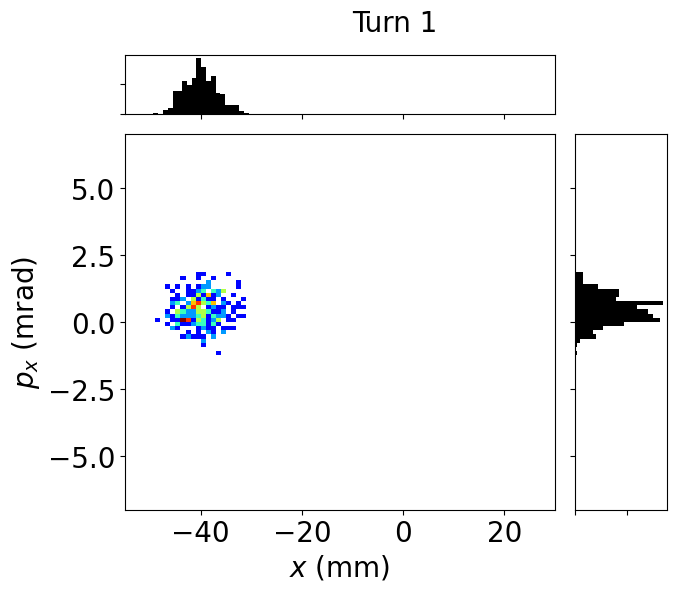

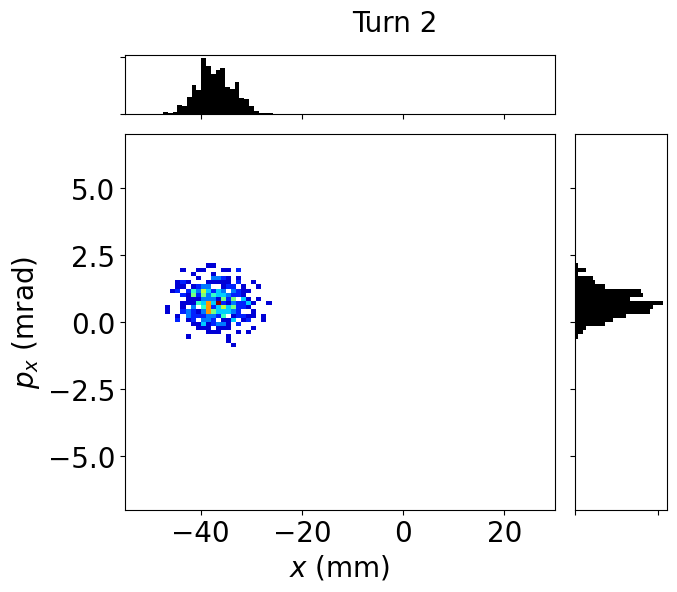

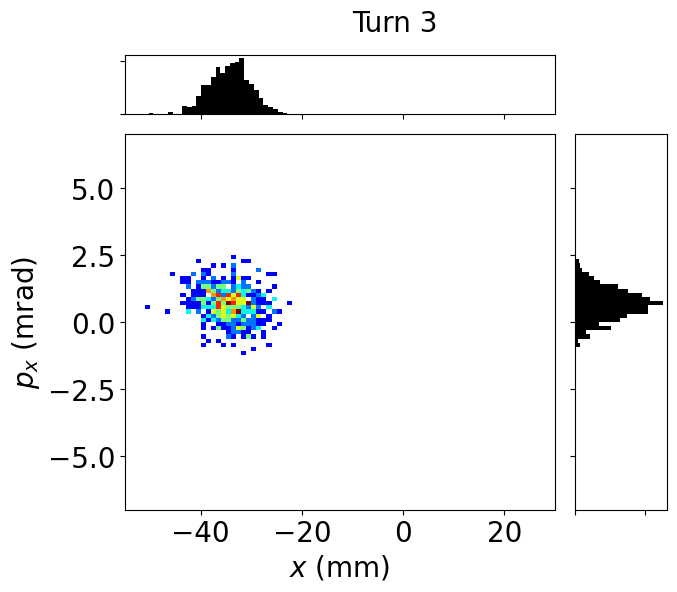

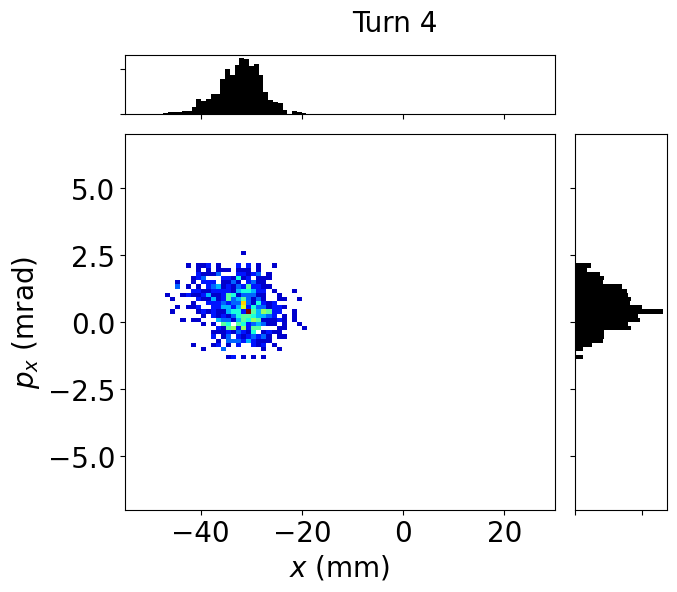

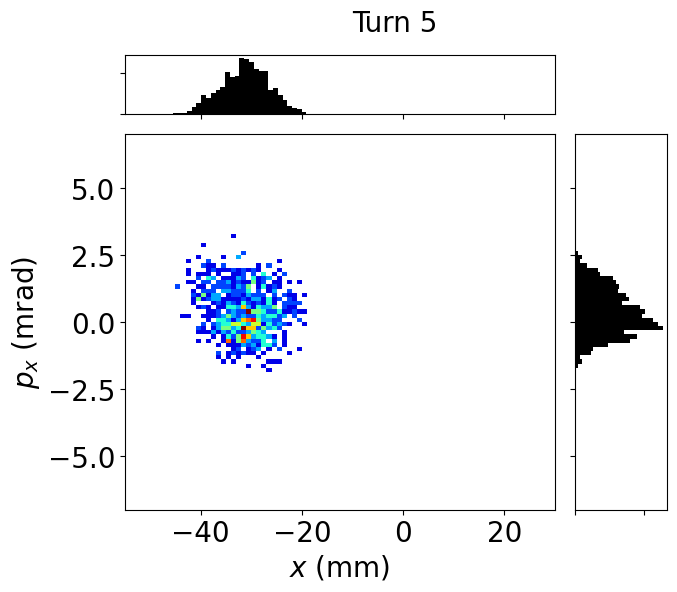

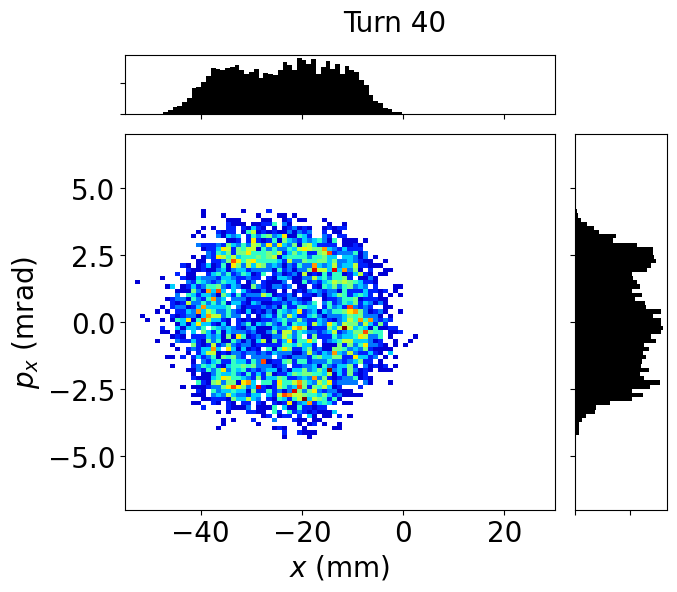

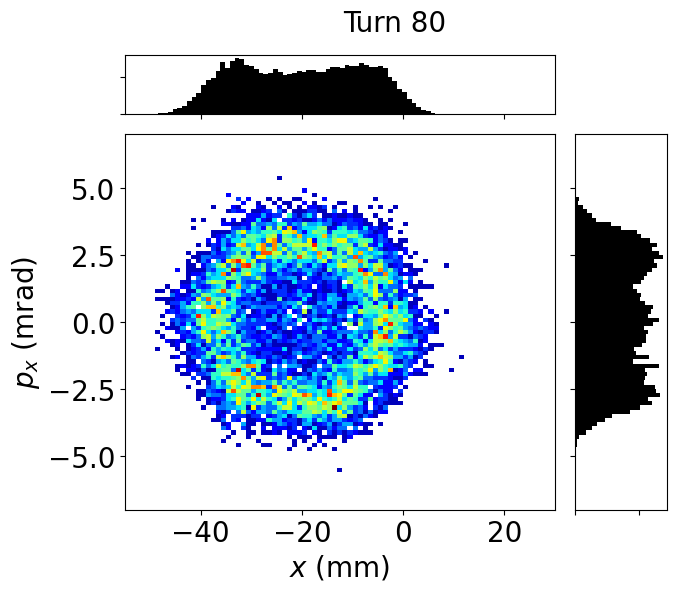

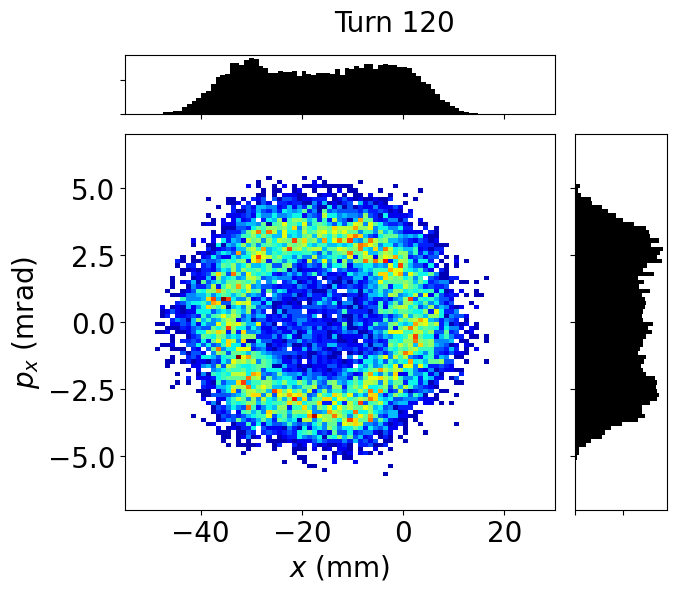

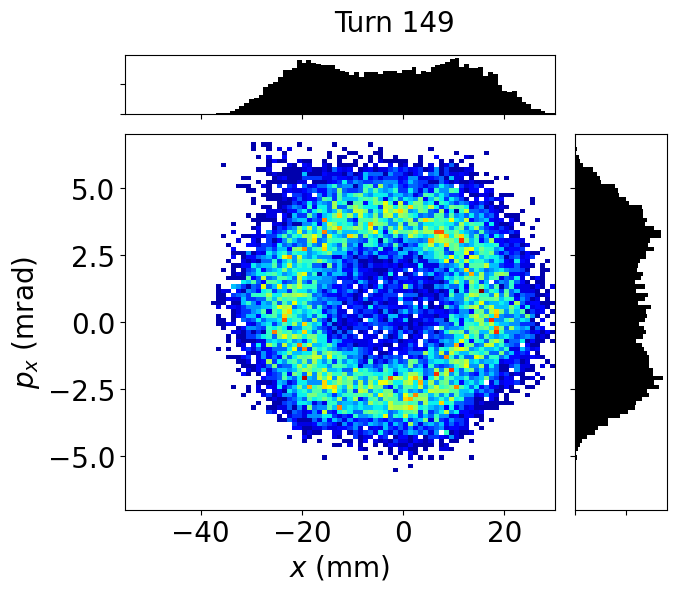

In [ ]:
#for i in range(len(particles_x)):
#for i in range(0, 150, 20):
for i in [1,2,3,4,5, 40, 80, 120, 149]:

        turn=i

        my_cmap = plt.cm.jet
        my_cmap.set_under('w',1)
        fontsize=20
        bins = 90
        vmin = 0.1

        fig = plt.figure(figsize=(8,6), facecolor='white')
        gs = gridspec.GridSpec(6, 6)
        ax = plt.subplot(gs[1:6, 0:4])
        ax_xDist = plt.subplot(gs[0, 0:4],sharex=ax)
        ax_yDist = plt.subplot(gs[1:6, 4],sharey=ax)

        x = np.array(particles_x[i])
        px = np.array(particles_px[i])

        ax.hist2d(x*1e3, px*1e3,
                bins=bins, cmap = my_cmap, vmin=vmin, 
                #range=[[min(df.x)*1e3, max(df.x)*1e3], [min(df.px)*1e3, max(df.px)*1e3]]#, norm=mcolors.PowerNorm(gamma)
                range = [[-60, 30], [-7, 7]]
                )

        #r.plot_resonance(ax)
        ax.set_xlabel('$x$ (mm)', fontsize=fontsize)
        ax.set_ylabel('$p_x$ (mrad)', fontsize=fontsize)
        ax.tick_params(axis='both', labelsize=fontsize)
        ax.set_xlim(-55, 30)
        ax.set_ylim(-7, 7)

        ax_xDist.hist(x*1e3,bins=bins,align='mid', color='black', range=(-55, 30))
        ax_xDist.tick_params(axis='x', labelleft=False, labelright=False, labeltop=False, labelbottom=False)
        ax_xDist.tick_params(axis='y', labelleft=False, labelright=False, labeltop=False, labelbottom=False)
        nsigmas = 2.5

        ax_yDist.hist(px*1e3,bins=bins,orientation='horizontal',align='mid', color='black', range=(-7, 7))
        ax_yDist.tick_params(axis='x', labelleft=False, labelright=False, labeltop=False, labelbottom=False)
        ax_yDist.tick_params(axis='y', labelleft=False, labelright=False, labeltop=False, labelbottom=False)
        nsigmas = 2.5

        plt.suptitle('Turn %s'%turn, fontsize=fontsize)
        fig.tight_layout()
        plt.show()